#Load Data

In [4]:
# 1. Install dependencies
!pip install -q kagglehub datasets
!pip install -q kagglehub datasets librosa

# 2. Login Kaggle
import kagglehub
kagglehub.login()
# Masukkan token kamu saat diminta

# 3. Download dataset dari Kaggle
import os
from datasets import load_from_disk

dataset_path = kagglehub.dataset_download("nalaprogroup/data-nalapro-project03")
print("Downloaded to:", dataset_path)

# 4. Cek isi folder dulu
print("\nDaftar file:")
for root, dirs, files in os.walk(dataset_path):
    print(root)

# 5. Load dataset
dataset = load_from_disk(dataset_path)
print("✅ Dataset berhasil di-load:", dataset)

# 6. Ekstrak data
def prepare_data(split_data):
    audio_arrays, transcriptions = [], []
    for sample in split_data:
        audio   = sample['audio']['array']
        orig_sr = sample['audio']['sampling_rate']

        if orig_sr != 16000:
            import librosa
            audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=16000)

        audio_arrays.append(audio)
        transcriptions.append(sample['transcription'])
    return audio_arrays, transcriptions

train_audio, train_text = prepare_data(dataset['train'])
val_audio,   val_text   = prepare_data(dataset['validation'])
test_audio,  test_text  = prepare_data(dataset['test'])

print(f"\nJumlah train  : {len(train_audio)}")
print(f"Jumlah val    : {len(val_audio)}")
print(f"Jumlah test   : {len(test_audio)}")
print(f"Sample rate   : {dataset['train'][0]['audio']['sampling_rate']} Hz")

Using Colab cache for faster access to the 'data-nalapro-project03' dataset.
Downloaded to: /kaggle/input/data-nalapro-project03

Daftar file:
/kaggle/input/data-nalapro-project03
/kaggle/input/data-nalapro-project03/validation
/kaggle/input/data-nalapro-project03/test
/kaggle/input/data-nalapro-project03/train
✅ Dataset berhasil di-load: DatasetDict({
    train: Dataset({
        features: ['audio', 'intent_class', 'transcription'],
        num_rows: 1800
    })
    validation: Dataset({
        features: ['audio', 'transcription', 'intent_class'],
        num_rows: 56
    })
    test: Dataset({
        features: ['audio', 'transcription', 'intent_class'],
        num_rows: 57
    })
})

Jumlah train  : 1800
Jumlah val    : 56
Jumlah test   : 57
Sample rate   : 16000 Hz
Kaggle credentials set.
Kaggle credentials successfully validated.


#Install & Import

In [5]:
!pip install -q transformers datasets accelerate peft jiwer

In [6]:
# =============================================
# 1. IMPORT
# =============================================
!pip install -q transformers datasets accelerate peft jiwer
import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from peft import get_peft_model, LoraConfig, TaskType
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import get_scheduler
from jiwer import wer

#Load processor & Model

In [7]:
# =============================================
# 2. LOAD PROCESSOR & MODEL
# =============================================
MODEL_NAME = "openai/whisper-small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

processor = WhisperProcessor.from_pretrained(MODEL_NAME)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

#Tambahkan LoRA

In [8]:
# =============================================
# 3. TAMBAHKAN LORA KE MODEL
# =============================================
!pip install -q -U torchao
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,      # ← ubah dari 32 ke 16 (ratio 2x, lebih stabil)
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,  # ← kurangi sedikit
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # cek berapa parameter yang dilatih
model = model.to(DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 107.8 MB/s eta 0:00:00


trainable params: 884,736 || all params: 242,619,648 || trainable%: 0.3647


In [16]:
# =============================================
# 4. DATASET CLASS
# =============================================
class WhisperDataset(Dataset):
    def __init__(self, audio_arrays, transcriptions, processor, sampling_rate=16000):
        self.audio_arrays   = audio_arrays
        self.transcriptions = transcriptions
        self.processor      = processor
        self.sampling_rate  = sampling_rate

    def __len__(self):
        return len(self.audio_arrays)

    def __getitem__(self, idx):
        inputs = self.processor(
            self.audio_arrays[idx],
            sampling_rate=self.sampling_rate,
            return_tensors="pt"
        )
        input_features = inputs.input_features.squeeze(0)

        # Ganti as_target_processor() → langsung pakai tokenizer
        labels = self.processor.tokenizer(
            self.transcriptions[idx],
            return_tensors="pt",
            truncation=True,
            max_length=128
        ).input_ids.squeeze(0)

        return input_features, labels

In [17]:
# =============================================
# 5. COLLATE FUNCTION & DATALOADER
# =============================================
def collate_fn(batch):
    input_features, labels = zip(*batch)
    input_features = torch.stack(input_features)

    # Padding labels
    max_len = max(l.size(0) for l in labels)
    padded_labels = torch.full((len(labels), max_len), -100, dtype=torch.long)
    for i, label in enumerate(labels):
        padded_labels[i, :label.size(0)] = label

    return input_features, padded_labels

train_dataset = WhisperDataset(train_audio, train_text, processor)
val_dataset   = WhisperDataset(val_audio,   val_text,   processor)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, collate_fn=collate_fn)


In [18]:
# =============================================
# 6. TRAINING SETUP
# =============================================
EPOCHS = 10           # tambah epoch, ada early stopping jadi aman
LR     = 5e-5         # ← turunkan dari 1e-4 ke 5e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
num_training_steps = EPOCHS * len(train_loader)
scheduler = get_scheduler(
    "cosine",           # ← ganti linear → cosine, lebih stabil
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),  # 10% warmup
    num_training_steps=num_training_steps
)

PATIENCE = 3
best_wer = float("inf")
patience_counter = 0
history = []

In [19]:
# =============================================
# 7. TRAINING LOOP
# =============================================
def evaluate_wer(model, processor, audio_arrays, transcriptions):
    model.eval()
    references, hypotheses = [], []

    forced_decoder_ids = processor.get_decoder_prompt_ids(
        language="en", task="transcribe"
    )

    with torch.no_grad():
        for i in range(len(audio_arrays)):
            inputs = processor(
                audio_arrays[i],
                sampling_rate=16000,
                return_tensors="pt"
            ).input_features.to(DEVICE)

            predicted_ids = model.generate(
                input_features=inputs,
                forced_decoder_ids=forced_decoder_ids
            )
            transcription = processor.batch_decode(
                predicted_ids, skip_special_tokens=True
            )[0]

            references.append(transcriptions[i])
            hypotheses.append(transcription)

    return wer(references, hypotheses)

def evaluate_loss(model, val_loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for input_features, labels in val_loader:
            input_features = input_features.to(DEVICE)
            labels         = labels.to(DEVICE)

            outputs = model(input_features=input_features, labels=labels)
            total_loss += outputs.loss.item()

    return total_loss / len(val_loader)

TRAIN_WER_SUBSET = 50

for epoch in range(EPOCHS):
    # Training — seluruh dataset
    model.train()
    total_loss = 0

    for input_features, labels in train_loader:
        input_features = input_features.to(DEVICE)
        labels         = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_features=input_features, labels=labels)
        loss    = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Evaluasi WER — train pakai subset, val pakai semua
    train_wer = evaluate_wer(model, processor,
                              train_audio[:TRAIN_WER_SUBSET],
                              train_text[:TRAIN_WER_SUBSET])
    val_wer   = evaluate_wer(model, processor, val_audio, val_text)
    val_loss  = evaluate_loss(model, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Train WER: {train_wer:.4f} | Val WER: {val_wer:.4f}")

    # Simpan model terbaik & early stopping
    if val_wer < best_wer:
        best_wer         = val_wer
        patience_counter = 0
        model.save_pretrained("best_whisper_lora")
        processor.save_pretrained("best_whisper_lora")
        print(f"   💾 Model tersimpan (WER: {val_wer:.4f})")
    else:
        patience_counter += 1
        print(f"   ⚠️ Tidak ada improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"   🛑 Early stopping! Training dihentikan di epoch {epoch+1}")
            break

    history.append({
        "Epoch"         : epoch + 1,
        "Training Loss" : round(avg_loss, 6),
        "Validation Loss": round(val_loss, 6),
        "Train WER"     : round(train_wer, 6),
        "Val WER"       : round(val_wer, 6)
    })

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

Epoch 1/10 | Train Loss: 3.4649 | Val Loss: 1.0257 | Train WER: 0.9349 | Val WER: 0.2222
   💾 Model tersimpan (WER: 0.2222)
Epoch 2/10 | Train Loss: 0.9507 | Val Loss: 0.7512 | Train WER: 0.8942 | Val WER: 0.2263
   ⚠️ Tidak ada improvement (1/3)
Epoch 3/10 | Train Loss: 0.5351 | Val Loss: 0.2861 | Train WER: 0.8663 | Val WER: 0.2236
   ⚠️ Tidak ada improvement (2/3)
Epoch 4/10 | Train Loss: 0.3015 | Val Loss: 0.2742 | Train WER: 0.8186 | Val WER: 0.2291
   ⚠️ Tidak ada improvement (3/3)
   🛑 Early stopping! Training dihentikan di epoch 4


In [20]:
# =============================================
# 8. HASIL AKHIR
# =============================================
print(f"\n{'='*50}")
print(f"✅ Training selesai!")
print(f"📊 Best Val WER : {best_wer:.4f}")
print(f"📊 Best Val Acc : {(1-best_wer)*100:.2f}%")
print(f"📊 Baseline WER : 0.4047")
print(f"📈 Improvement  : {(0.4047 - best_wer)*100:.2f}%")

import pandas as pd

df = pd.DataFrame(history)
display(df)

# Tabel hasil transcription val set
print("\n📋 Hasil Transcription Val Set:")

references         = []
hypotheses         = []
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="en", task="transcribe"
)

model.eval()
with torch.no_grad():
    for i in range(len(val_audio)):
        inputs = processor(
            val_audio[i],
            sampling_rate=16000,
            return_tensors="pt"
        ).input_features.to(DEVICE)

        predicted_ids = model.generate(
            input_features=inputs,
            forced_decoder_ids=forced_decoder_ids
        )
        transcription = processor.batch_decode(
            predicted_ids, skip_special_tokens=True
        )[0]

        references.append(val_text[i])
        hypotheses.append(transcription)

df_transcription = pd.DataFrame({
    "No"        : range(1, len(val_audio) + 1),
    "Reference" : references,
    "Hypothesis": hypotheses,
})
display(df_transcription)


✅ Training selesai!
📊 Best Val WER : 0.2222
📊 Best Val Acc : 77.78%
📊 Baseline WER : 0.4047
📈 Improvement  : 18.25%


,Epoch,Training Loss,Validation Loss,Train WER,Val WER
0,1,3.464870,1.025720,0.934884,0.222222
1,2,0.950688,0.751185,0.894186,0.226337
2,3,0.535071,0.286107,0.866279,0.223594



📋 Hasil Transcription Val Set:


,No,Reference,Hypothesis
0,1,I need information about a business phone,I need information about a business loan
1,2,hi I'm an account holder have been for 18 year...,hi I'm an account holder have been for 10 year...
2,3,I'm having some fun and I'm wondering if you a...,oh I'm asking for a project transaction to my ...
3,4,I need to change my address can I do that here...,I need to change my address can I do that here...
4,5,I would like to change my address,I would like to change my address
5,6,I would like to deposit money what's the best ...,I would like to deposit money what's the best ...
6,7,how much money can you withdrawal,how much money can you withdraw
7,8,freeze my debit card I want to stop at all tra...,I want to freeze my debit card I want to stop ...
8,9,I am attempting to make a high-value purchase ...,I am attempting to make a high value purchase ...
9,10,can you tell me about direct debit,can you tell me about direct debit


In [21]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "best_whisper_lora",
    "/content/drive/MyDrive/Project3/models/best_whisper_lora"
)
print("✅ Model LoRA tersimpan di Google Drive!")

Mounted at /content/drive
✅ Model LoRA tersimpan di Google Drive!


#Visualisasi

📊 Tabel Hasil Training:


,Epoch,Train Loss,Val Loss,Train WER,Val WER
0,1,3.464870,1.025720,0.934884,0.222222
1,2,0.950688,0.751185,0.894186,0.226337
2,3,0.535071,0.286107,0.866279,0.223594


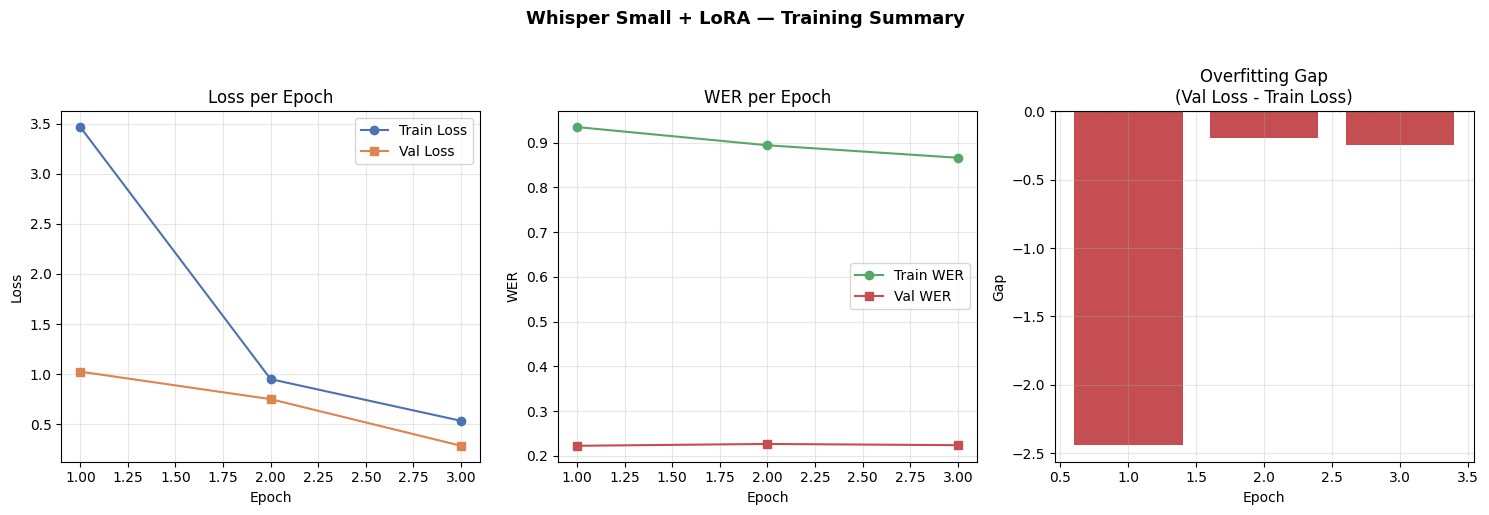

✅ Grafik tersimpan sebagai training_summary.png


In [22]:
# =============================================
# 9. VISUALISASI HASIL TRAINING
# =============================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Tabel ---
df_history = pd.DataFrame(history)
df_history.columns = ["Epoch", "Train Loss", "Val Loss", "Train WER", "Val WER"]
print("📊 Tabel Hasil Training:")
display(df_history)

# --- Grafik ---
epochs = df_history["Epoch"]

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# Plot 1: Loss
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs, df_history["Train Loss"], marker="o", label="Train Loss", color="#4C72B0")
ax1.plot(epochs, df_history["Val Loss"],   marker="s", label="Val Loss",   color="#DD8452")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: WER
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs, df_history["Train WER"], marker="o", label="Train WER", color="#55A868")
ax2.plot(epochs, df_history["Val WER"],   marker="s", label="Val WER",   color="#C44E52")
ax2.set_title("WER per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("WER")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Train Loss vs Val Loss gap (untuk deteksi overfitting)
ax3 = fig.add_subplot(gs[2])
gap = df_history["Val Loss"] - df_history["Train Loss"]
ax3.bar(epochs, gap, color=["#4C72B0" if g >= 0 else "#C44E52" for g in gap])
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_title("Overfitting Gap\n(Val Loss - Train Loss)")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Gap")
ax3.grid(True, alpha=0.3)

plt.suptitle("Whisper Small + LoRA — Training Summary", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("training_summary.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Grafik tersimpan sebagai training_summary.png")